Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV params: {'knn__metric': 'minkowski', 'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV F1(FAIL): 0.7180562462511328

🎯 MODEL PERFORMANCE (Binary PASS/FAIL)
Accuracy: 0.7390

Classification Report (PASS=0, FAIL=1):
              precision    recall  f1-score   support

        PASS     0.8264    0.7078    0.7625       592
        FAIL     0.6491    0.7843    0.7103       408

    accuracy                         0.7390      1000
   macro avg     0.7378    0.7460    0.7364      1000
weighted avg     0.7541    0.7390    0.7412      1000

ROC-AUC: 0.8386

Suggested threshold by Youden's J: 0.415

Classification Report at optimal threshold:
              precision    recall  f1-score   support

        PASS     0.8788    0.6368    0.7385       592
        FAIL     0.6235    0.8725    0.7273       408

    accuracy                         0.7330      1000
   macro avg     0.7511    0.7547    0.7329  

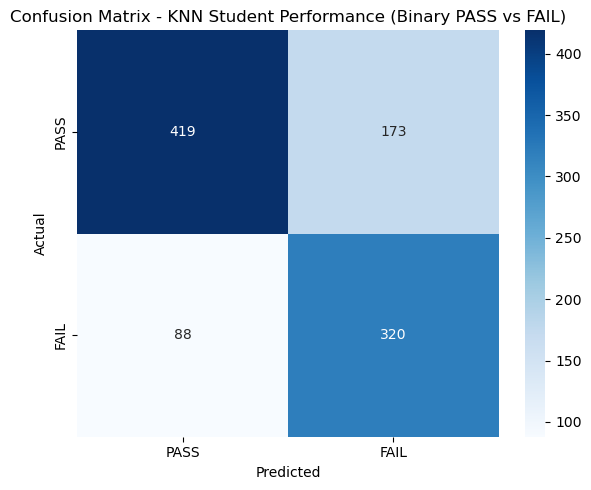


Saved files:
 - knn_pass_fail_pipeline.pkl
 - confusion_matrix_binary.png


In [1]:
# ============================
# Binary PASS/FAIL KNN Trainer
# ============================

# STEP 0 — Imports & warning control
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline as SkPipeline

# imbalanced-learn: SMOTE inside CV via ImbPipeline to avoid leakage
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import make_scorer, f1_score

# STEP 1 — Configuration for data/columns
CSV_PATH = "Students Performance Dataset.csv" 

# Columns to drop (IDs or leaky targets/aggregates)
LEAKY_OR_ID_COLS = [
    "Student_ID", "First_Name", "Last_Name", "Email",
    "Final_Score", "Total_Score"  # direct/indirect label info
]

# Numeric feature names expected in the CSV
NUM_FEATURES = [
    "Attendance (%)",
    "Quizzes_Avg",
    "Assignments_Avg",
    "Midterm_Score",
    "Participation_Score",
    "Projects_Score",
    "Study_Hours_per_Week",
    "Sleep_Hours_per_Night",
    "Stress_Level (1-10)"
]

# Categorical features
CAT_FEATURES = [
    "Extracurricular_Activities"  # e.g., "Yes"/"No"
]

# Multiclass grade column (A/B/C/D/F)
TARGET_COL = "Grade"

# STEP 2 — Load data
df = pd.read_csv(CSV_PATH)

# STEP 3 — Drop leaky/ID columns (safe no-op if not present)
cols_to_drop = [c for c in LEAKY_OR_ID_COLS if c in df.columns]
df = df.drop(columns=cols_to_drop)

# STEP 4 — Sanity check: required columns present?
required_cols = set(NUM_FEATURES + CAT_FEATURES + [TARGET_COL])
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

# STEP 5 — Handle missing values (SIMPLE baseline approach)

# Numeric -> median; Categorical -> mode
for col in NUM_FEATURES:
    df[col] = df[col].fillna(df[col].median())
for col in CAT_FEATURES:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

# STEP 6 — Map A/B/C/D/F to PASS/FAIL, then encode to 0/1
# A/B/C -> PASS ; D/F -> FAIL
grade_to_binary = {"A": "PASS", "B": "PASS", "C": "PASS", "D": "FAIL", "F": "FAIL"}
df["Grade_Binary"] = df[TARGET_COL].map(grade_to_binary)

# Guardrail: unexpected labels
if df["Grade_Binary"].isna().any():
    bad = df.loc[df["Grade_Binary"].isna(), TARGET_COL].unique().tolist()
    raise ValueError(f"Unexpected grade labels found: {bad}. Expected only A/B/C/D/F.")

# Encode to 0/1 while ensuring FAIL==1 (positive class)
label_encoder_target = LabelEncoder()
df["Grade_Binary_Encoded"] = label_encoder_target.fit_transform(df["Grade_Binary"])
classes_in_order = list(label_encoder_target.classes_)
# If encoder order isn't ["PASS","FAIL"], remap manually to enforce FAIL==1
if classes_in_order != ["PASS", "FAIL"]:
    label_encoder_target = LabelEncoder()  # (kept for parity with your original code)
    mapping = {"PASS": 0, "FAIL": 1}
    y = df["Grade_Binary"].map(mapping).values
else:
    # PASS=0, FAIL=1 with this class order
    y = df["Grade_Binary_Encoded"].values

# STEP 7 — Train/test split (stratified to preserve class balance)
X = df[NUM_FEATURES + CAT_FEATURES].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# STEP 8 — Preprocessing pipeline
# Numeric: MinMaxScaler (good for distance-based KNN)
# Categorical: OneHotEncoder (ignore unseen categories at inference)
numeric_transformer = SkPipeline(steps=[
    ("scaler", MinMaxScaler())
])
categorical_transformer = SkPipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_FEATURES),
        ("cat", categorical_transformer, CAT_FEATURES)
    ],
    remainder="drop"
)

# STEP 9 — Full modeling pipeline with SMOTE inside CV folds
# IMPORTANT: Using ImbPipeline so SMOTE runs only on training folds during CV
pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("knn", KNeighborsClassifier())
])

# STEP 10 — Hyperparameter grid for KNN
param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["minkowski"],  # can add 'euclidean','manhattan' if desired
    "knn__p": [1, 2],              # p=1 -> Manhattan, p=2 -> Euclidean (for minkowski)
}

# Optimize F1 for FAIL (the positive/minority/at-risk class)
f1_fail = make_scorer(f1_score, pos_label=1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=f1_fail,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# STEP 11 — Train via GridSearchCV
grid.fit(X_train, y_train)
print("Best CV params:", grid.best_params_)
print("Best CV F1(FAIL):", grid.best_score_)

# STEP 12 — Evaluate on untouched test set
best_model = grid.best_estimator_

# Default threshold = 0.50 on P(FAIL)
y_proba = best_model.predict_proba(X_test)[:, 1]  # probability of FAIL=1
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("\n🎯 MODEL PERFORMANCE (Binary PASS/FAIL)")
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report (PASS=0, FAIL=1):")
print(classification_report(y_test, y_pred, target_names=["PASS", "FAIL"], digits=4))

# Threshold-independent metric (helpful with imbalance)
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

# STEP 13 — Optional operating point via Youden's J (max TPR - FPR)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
youden_idx = np.argmax(tpr - fpr)
opt_threshold = thresholds[youden_idx]
print(f"\nSuggested threshold by Youden's J: {opt_threshold:.3f}")

y_pred_opt = (y_proba >= opt_threshold).astype(int)
print("\nClassification Report at optimal threshold:")
print(classification_report(y_test, y_pred_opt, target_names=["PASS", "FAIL"], digits=4))

# STEP 14 — Confusion matrix (default 0.50 threshold)
cm = confusion_matrix(y_test, y_pred, labels=[0,1])  # rows: actual PASS, FAIL
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["PASS","FAIL"], yticklabels=["PASS","FAIL"])
plt.title("Confusion Matrix - KNN Student Performance (Binary PASS vs FAIL)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_binary.png", dpi=150)
plt.show()

# STEP 15 — Persist artifacts

joblib.dump(best_model, "knn_pass_fail_pipeline.pkl")
print("\nSaved files:")
print(" - knn_pass_fail_pipeline.pkl")
print(" - confusion_matrix_binary.png")

# STEP 16 — (Example) Scoring new data with the same schema (commented)
# new_df = pd.DataFrame([{
#     "Attendance (%)": 85,
#     "Quizzes_Avg": 76,
#     "Assignments_Avg": 80,
#     "Midterm_Score": 62,
#     "Participation_Score": 70,
#     "Projects_Score": 74,
#     "Study_Hours_per_Week": 10,
#     "Sleep_Hours_per_Night": 7,
#     "Stress_Level (1-10)": 5,
#     "Extracurricular_Activities": "No"
# }])
# proba_fail = best_model.predict_proba(new_df)[:,1][0]
# pred_label = "FAIL" if proba_fail >= 0.5 else "PASS"
# print(f"Predicted: {pred_label}  |  P(FAIL)={proba_fail:.3f}")
